# ***Diabetes_Dataset***

***Introduction***


This dataset provides a comprehensive collection of demographic, behavioral,
and clinical information for 100,000 individuals, designed to support advanced research and predictive modeling
in the field of diabetes. By integrating key variables such as age, gender, race, location, BMI, HbA1c levels,
blood glucose levels, hypertension, heart disease, and smoking history, the dataset enables in-depth analyses of 
both biological and sociodemographic determinants of diabetes.

## ***Part 1:Data Loading***

Loading and Reading a data file

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [8]:
df=pd.read_csv('diabetes_dataset.csv.csv')

df   # Jupyter shortcut for displaying the object (not exactly "printing")
display(df) # displays the df in a rich, nicely formatted way

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."


In [7]:
# Take a copy of your data 
df_copy= df.copy()
df_copy

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."


## ***Part 2: Initial Data Inspection/Exploration***

Before conducting any analysis, it is essential to inspect the diabetes dataset to gain a preliminary understanding of its structure and quality. This includes viewing the first few rows, checking data types, confirming non-null counts, and identifying the overall shape of the dataset. These steps help reveal common issues in medical data, such as missing clinical values, zeros used in place of missing measurements, incorrect data types, or unusual outliers. Early detection of these problems ensures that appropriate cleaning and preprocessing steps can be applied later, allowing for more accurate and reliable analysis.

### Preview Dataset and its dimensions

In [11]:
display(df.head())
display(df.tail())
#Display the first 5 rows of the DataFrame using the .head() 
#method to get a glimpse of the data. You can also display the 5 last rows using the .head() method

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."
99999,2016,Male,13.0,Wyoming,0,0,0,1,0,0,0,No Info,17.16,5.0,90,0,"Young patient, generally lower risk but needs ..."


In [12]:
df.info()
#The .info() method provides a concise summary of the DataFrame. 
#It includes the index dtype and columns, non-null values and their data types, and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [13]:
df.shape
#The .shape attribute of a DataFrame returns the number of rows and the number of columns.

(100000, 17)

### Renaming columns

In [28]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:AfricanAmerican':'race_AfricanAmerican'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race_Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [29]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Asian':'race_Asian'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race_Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [30]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Caucasian':'race_Caucasian'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [31]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Other':'race_Other'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

In [32]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'race:Hispanic':'race_Hispanic'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race_AfricanAmerican  race_Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race_Caucasian  race_Hispanic  race_Other  hypertension  heart_disease  \
0                   0    

In [14]:
# Rename the smoking_history column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'smoking_history':'Smoking_Status'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race:AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

In [15]:
# Rename the clinical_notes column to a name that makes more sense and prints the df with the renamed column.
df.rename(columns={'clinical_notes':'Clinical_Summary'},inplace=True)
print("Column names after renaming:")
print(df)

Column names after renaming:
       year  gender   age location  race:AfricanAmerican  race:Asian  \
0      2020  Female  32.0  Alabama                     0           0   
1      2015  Female  29.0  Alabama                     0           1   
2      2015    Male  18.0  Alabama                     0           0   
3      2015    Male  41.0  Alabama                     0           0   
4      2016  Female  52.0  Alabama                     1           0   
...     ...     ...   ...      ...                   ...         ...   
99995  2018  Female  33.0  Wyoming                     0           0   
99996  2016  Female  80.0  Wyoming                     0           1   
99997  2018    Male  46.0  Wyoming                     0           1   
99998  2018  Female  51.0  Wyoming                     1           0   
99999  2016    Male  13.0  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0                   0    

### Understanding data types

Understanding column data types is a critical step in analyzing the diabetes dataset, as they determine how variables can be processed and interpreted. Incorrect data types may lead to analytical errors or prevent numerical computations. Although Pandas infers data types automatically, verifying and correcting them ensures accuracy and reliability in subsequent analysis.

In [16]:
print("Data types of each column:")
display(df.dtypes)
#Display the data types of each column in the df DataFrame.

Data types of each column:


year                      int64
gender                   object
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
Smoking_Status           object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
Clinical_Summary         object
dtype: object

***Interpretation:*** All columns have appropriate types (numeric for measurements, object for categorical data). No conversions are needed.

## Part 3: Primary Data Cleaning & Preprocessing




### Handling Missing  Values

Identifying missing values is essential, as unaddressed missing values may distort statistical results or degrade model performance.

In [17]:
# Check for missing values
display(df.isnull().sum())

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
Smoking_Status          0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
Clinical_Summary        0
dtype: int64

***Interpretation:*** There are no missing entries in the dataset, so we can proceed directly to analysis and preprocessing.

### Handling duplicates


In [20]:
#the `.duplicated()` method. This method returns a boolean Series indicating whether each row is a duplicate of a previous row. By default, it considers all columns to identify duplicates.
print("Number of duplicate rows:", df.duplicated().sum())

# Demonstrate dropping duplicates
print("\nShape of DataFrame before dropping duplicates:", df.shape)
# To remove duplicate rows, you can use the `.drop_duplicates()` method. This method returns a new DataFrame with duplicate rows removed. By default, it keeps the first occurrence of a duplicate row.
df_no_duplicates = df.drop_duplicates()
print("Shape of DataFrame after dropping duplicates:", df_no_duplicates.shape)

Number of duplicate rows: 14

Shape of DataFrame before dropping duplicates: (100000, 17)
Shape of DataFrame after dropping duplicates: (99986, 17)


## Part 4:Exploratory Data Analysis: Primary Statistics


### Calculating Basic Statistics

Calculating basic descriptive statistics is a fundamental step in understanding the distribution, central tendency, and variability of your data.

For **numerical data**, descriptive statistics like count, mean, median, standard deviation, minimum, maximum, and quartiles provide a summary of the data's distribution.

For **categorical data**, understanding the frequency distribution of each category is crucial. This involves counting the occurrences of each unique value in a categorical column.

### Exploring Numerical Columns

### Exploring Numerical Data: Distribution and Summary Statistics

Exploring the distribution and summary statistics of numerical variables is a fundamental step in understanding the nature of your data. It helps to grasp the typical values, how spread out the data is, and the shape of its distribution.

Key aspects to consider include:

- **Central Tendency:** Measures like the mean, median, and mode indicate the center or typical value of the data.
- **Dispersion:** Measures like the standard deviation, variance, and interquartile range (IQR) describe the spread or variability of the data.
- **Shape of Distribution:** Understanding whether the data is symmetric or skewed, and if it has multiple peaks (modality), provides insights into the underlying patterns.

Summary statistics provide a quick numerical snapshot of these characteristics.

In [23]:
print("Descriptive statistics for numerical columns:")
display(df.describe()) # by defaut works only with numercial columns only

Descriptive statistics for numerical columns:


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


The .describe() output for the diabetes dataset provides key descriptive statistics that summarize the distribution of each numerical variable:

***count:*** Shows 100,000 non-null observations for all variables, indicating no missing data.

***mean:*** Represents the average value—for example, the mean age is approximately 41.89, and the mean BMI is about 27.32.

***std:*** Indicates variability in the data; for instance, blood glucose level has a high standard deviation (~40.7), suggesting wide variation among patients.

***min:*** The smallest recorded value in each column (e.g., minimum age is 0.08 years).

***25% (Q1):*** The value below which 25% of observations fall, helping to understand lower-range distributions.

***50% (Median):*** The midpoint of the data—for example, median age (43) and median BMI (~27.32) reflect typical patient characteristics.

***75% (Q3):*** The value below which 75% of the data falls, showing the upper-middle range of each variable.

***max:*** The largest observed value in the column (e.g., maximum blood glucose level is 200).

These statistics provide a clear and concise overview of the central tendency, spread, and range of values within the diabetes dataset, forming the foundation for deeper analysis.

In [24]:
# 1. Calculating medians for key numerical variables
display("Median Age:", df.age.median())
display("Median BMI:", df.bmi.median())
display("Median HbA1c Level:", df.hbA1c_level.median())
display("Median Blood Glucose Level:", df.blood_glucose_level.median())

# 2. Listing unique values for categorical variables
display("Unique Locations:", df.location.unique())


# 3. Counting occurrences of categorical variables
display("Frequency of Diabetes Status (0=No, 1=Yes):")
display(df.diabetes.value_counts())
display("Frequency of Smoking Status:")
display(df.Smoking_Status.value_counts())


# 4. Grouping data and calculating mean values
# Mean BMI, HbA1c, and Blood Glucose by Diabetes Status
grouped_by_diabetes = df.groupby('diabetes')[['bmi', 'hbA1c_level', 'blood_glucose_level']].mean()
display("Mean values by Diabetes Status:")
display(grouped_by_diabetes)


# 5. Sorting data by a numerical column
# Sort patients by highest blood glucose level
sorted_by_glucose = df.sort_values(by='blood_glucose_level', ascending=False)
display("Top 10 patients by Blood Glucose Level:")
display(sorted_by_glucose.head(10))


'Median Age:'

43.0

'Median BMI:'

27.32

'Median HbA1c Level:'

...

Smoking_Status
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

'Mean values by Diabetes Status:'

,bmi,hbA1c_level,blood_glucose_level
diabetes,,,
0,26.887163,5.396761,132.852470
1,31.988382,6.934953,194.094706


'Top 10 patients by Blood Glucose Level:'

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,Smoking_Status,bmi,hbA1c_level,blood_glucose_level,diabetes,Clinical_Summary
99748,2015,Female,75.0,Wyoming,0,0,0,1,0,0,1,former,39.84,6.2,300,1,Elderly patient with increased risk of chronic...
99763,2015,Male,55.0,Wyoming,1,0,0,0,0,0,0,never,39.56,6.1,300,1,"Obese category, increased risk for diabetes an..."
99865,2018,Male,79.0,Wyoming,0,0,0,1,0,0,0,never,27.88,6.6,300,1,Elderly patient with increased risk of chronic...
99942,2016,Male,65.0,Wyoming,0,0,0,1,0,0,0,ever,27.32,8.2,300,1,Elderly patient with increased risk of chronic...
83143,2019,Male,72.0,Rhode Island,0,0,0,0,1,0,0,No Info,30.98,7.0,300,1,Elderly patient with increased risk of chronic...
48404,2019,Female,45.0,Minnesota,0,0,0,1,0,0,0,current,38.33,9.0,300,1,"Obese category, increased risk for diabetes an..."
48048,2015,Male,72.0,Minnesota,0,0,0,0,1,0,0,No Info,26.31,6.5,300,1,Elderly patient with increased risk of chronic...
48128,2016,Male,60.0,Minnesota,0,1,0,0,0,0,0,not current,26.06,7.0,300,1,"Overweight, advised dietary and exercise modif..."
12086,2019,Female,71.0,Colorado,0,1,0,0,0,0,0,No Info,50.57,7.0,300,1,Elderly patient with increased risk of chronic...
11589,2019,Female,50.0,Colorado,0,0,0,0,1,0,0,current,30.37,6.6,300,1,"Obese category, increased risk for diabetes an..."


***Median values:***

The median age of 43 indicates that half of the patients are younger than 43 and half are older.

The median BMI of 27.32 suggests that the typical patient falls in the overweight category.

The median HbA1c level of 5.8% and median blood glucose level of 140 mg/dL indicate that many patients are near or above the threshold for diabetes diagnosis, highlighting the risk in this population.

***Unique locations:***

Patients are distributed across all U.S. states and territories, showing a geographically diverse dataset.

***Diabetes and smoking status frequencies:***

Most patients (91,500 out of 100,000) do not have diabetes, while 8,500 have diabetes.

Smoking status shows diversity, with the largest groups being “No Info” and “never smokers”, but also including former, current, and other categories.

***Mean values by diabetes status:***

Patients with diabetes have higher average BMI (31.99 vs 26.89), higher HbA1c levels (6.93 vs 5.40), and higher blood glucose levels (194.09 vs 132.85) compared to non-diabetic patients.

This confirms the expected association between diabetes and elevated health indicators.

***Top 10 patients by blood glucose:***

Sorting by blood glucose levels highlights extreme cases (all at 300 mg/dL), mostly older adults with high BMI or HbA1c.

This allows identification of high-risk patients for further analysis or intervention.

***Overall:***
The dataset shows a diverse population, a clear difference in health indicators between diabetic and non-diabetic patients, and identifies patients with critically high blood glucose, which is useful for understanding risk patterns and guiding preventive strategies.

Further statistics: Correlation (numerical data)


Correlation and Covariance in the Diabetes Dataset

Understanding how different health measurements relate to each other is an important part of exploring the diabetes dataset. Correlation is statistical measures that help us see how numerical variables, such as age, bmi, hbA1c_level, and blood_glucose_level, change together.


Correlation standardizes this relationship, giving a value between -1 and +1.

A correlation of +1 indicates a perfect positive relationship (both variables increase together).

A correlation of -1 indicates a perfect negative relationship (one increases while the other decreases).

A correlation of 0 indicates no linear relationship.

In this dataset, correlation is particularly useful to understand how key health indicators—like BMI, HbA1c, and blood glucose—are related. It helps identify patterns, detect risk factors for diabetes, and select relevant variables for further analysis or modeling.

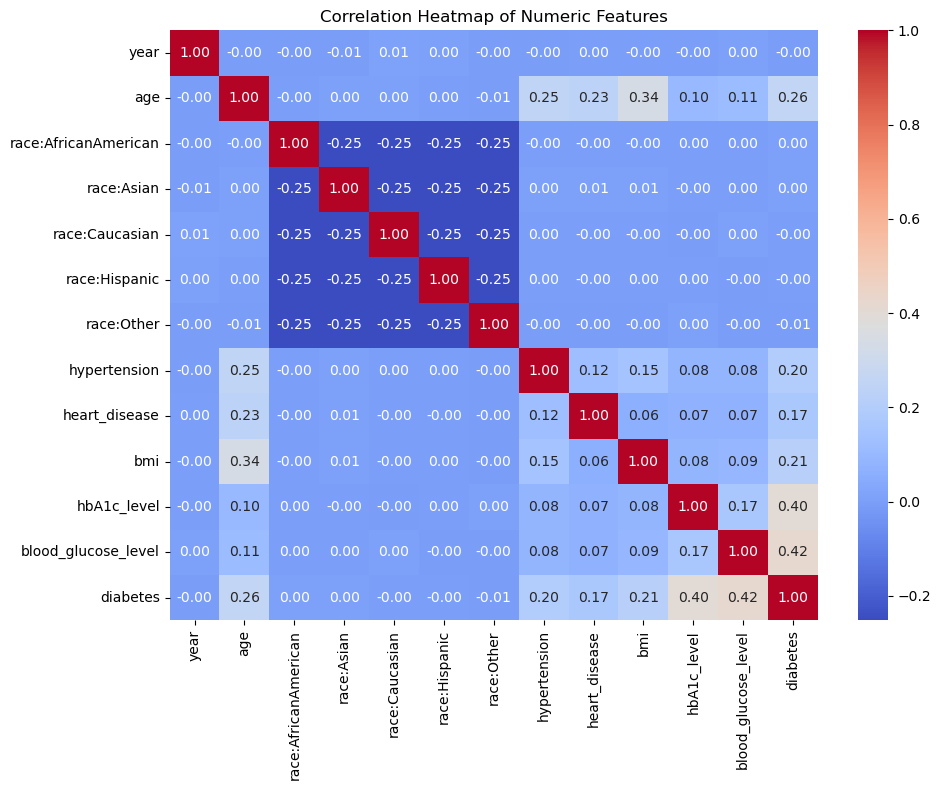

In [31]:
import matplotlib.gridspec as gridspec
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

# Correlation Heatmap

plt.figure(figsize=(10,8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()




Relationship with diabetes:

The strongest positive correlations with diabetes are seen for:

Blood glucose level (0.42)

HbA1c level (0.40)

BMI (0.21)

Hypertension (0.20)

Heart disease (0.17)

This means that patients with higher blood sugar, higher HbA1c, higher BMI, or cardiovascular issues are more likely to have diabetes.

Age:

Age (0.26) has a moderate positive correlation with diabetes, suggesting older patients are slightly more likely to have diabetes.

Race variables:

Race indicators have correlations close to zero with diabetes, suggesting no strong linear relationship between race and diabetes in this dataset.

Other health measures:

BMI, hypertension, and heart disease show small to moderate positive correlations with diabetes, supporting the known association between obesity, cardiovascular health, and diabetes risk


The correlation analysis confirms that blood sugar levels, HbA1c, BMI, and cardiovascular conditions are the strongest indicators associated with diabetes in this dataset, while demographic variables like race have minimal linear effect. This insight is useful for identifying key risk factors and selecting features for further analysis or predictive modeling.

Key observations from the dataset:

Age and BMI (50.42): Older patients tend to have higher BMI

Blood glucose and HbA1c (7.27): Both increase together, as expected since HbA1c reflects average blood glucose

Blood glucose and diabetes (4.76): Higher blood glucose is associated with diabetes

BMI and diabetes (0.40): Higher BMI also tends to be associated with diabetes

Hypertension and blood glucose (0.90): Higher blood glucose often occurs with hypertension

Other variables:

Race variables show very small covariances with health outcomes → minimal linear relationship

Heart disease shows modest covariances with age, BMI, and blood glucose → aligns with expected health trends

Summary:

Covariance confirms that age, BMI, blood glucose, and HbA1c vary together with diabetes-related outcomes

Magnitudes are hard to compare due to differing units → correlation is often better for interpreting strength of relationships

In [10]:
gender = df['gender'].value_counts().reset_index().rename(columns={0:'No of entries'})
gender

,gender,count
0,Female,58552
1,Male,41430
2,Other,18


In [12]:
df['gender'] = df['gender'].replace("Other", np.nan)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [13]:
gender = df['gender'].value_counts().reset_index().rename(columns={0:'No of entries'})
gender

,gender,count
0,Female,58570
1,Male,41430


Interpretation: we replaced "other" with the most common value in gender and the female still has more entries that male 

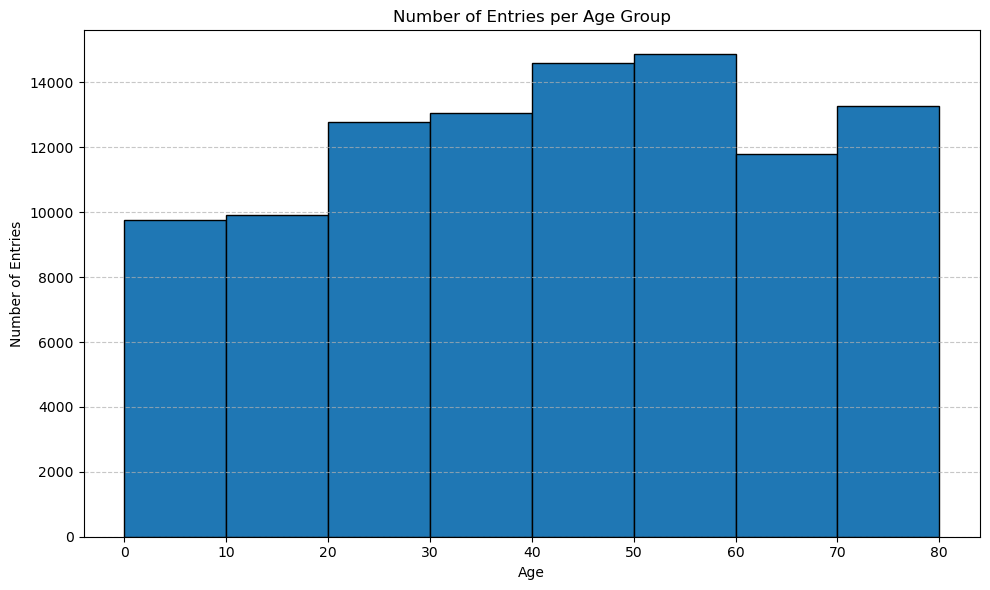

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=[0,10,20,30,40,50,60,70,80], edgecolor='black')
plt.title('Number of Entries per Age Group')
plt.xlabel('Age')
plt.ylabel('Number of Entries')
plt.xticks([0,10,20,30,40,50,60,70,80])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation:
Ages between 50-60 has the most entries and Ages 0-10 has the lowest number of entries, All the age groups are represented fairly in the dataset

In [18]:
#Exploring the races 
race = df[['race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic','race:Other']]


In [19]:
zeros = (race==0).sum()
ones = (race==1).sum()
race_counts = pd.DataFrame({'zero':zeros,'one':ones})
race_counts

,zero,one
race:AfricanAmerican,79777,20223
race:Asian,79985,20015
race:Caucasian,80124,19876
race:Hispanic,80112,19888
race:Other,80002,19998


Interpretation:
The distribution of the target classes across racial groups shows a consistent and balanced pattern, 
with all races exhibiting approximately 80% of observations in the “zero” class and 20% in the “one” class. African American, Asian,
Caucasian, Hispanic, and Other groups all follow this same ratio with only minimal variation, suggesting that race does not introduce any notable imbalance or disproportion in the outcome variable. This uniformity indicates that the target variable is distributed similarly across racial categories,
implying that race is unlikely to be a strong predictor of class differences in this dataset.

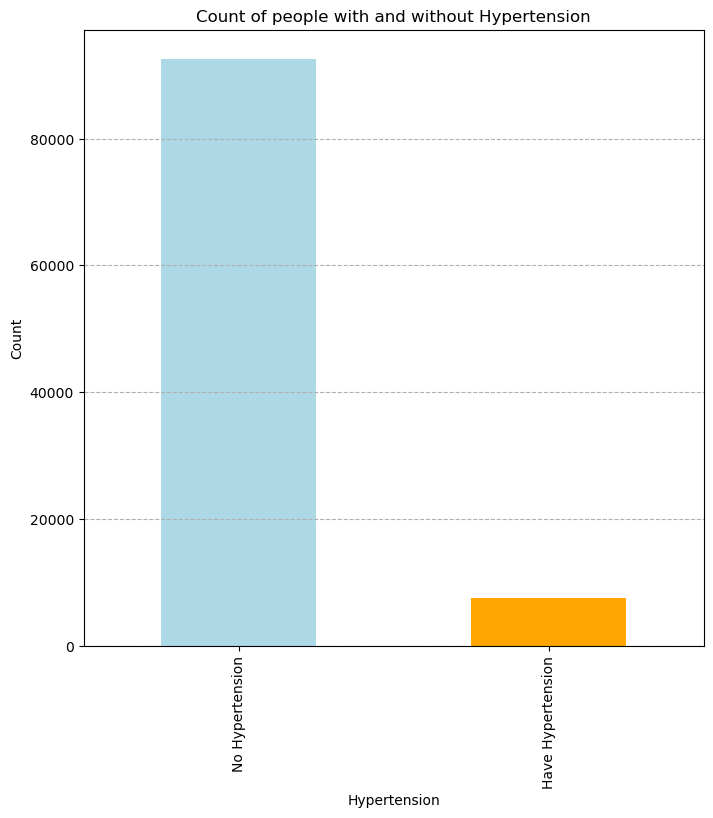

In [23]:
BP = df['hypertension'].value_counts()
BP.index=['No Hypertension','Have Hypertension']
BP

plt.figure(figsize=(8,8))
BP.plot(kind='bar', color=['lightblue','orange'], xlabel='Hypertension', ylabel='Count', title='Count of people with and without Hypertension')
plt.grid(axis='y', linestyle='--')
plt.show()

Most of the people do not have hypertension

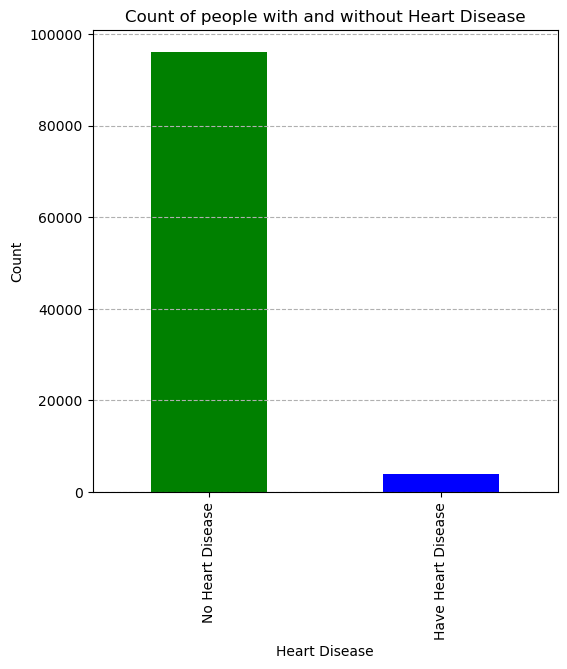

In [24]:
heart_disease = df['heart_disease'].value_counts()
heart_disease.index=['No Heart Disease', 'Have Heart Disease']
heart_disease


plt.figure(figsize=(6,6))
heart_disease.plot(kind='bar', color=['green','blue'], xlabel='Heart Disease', ylabel='Count', title='Count of people with and without Heart Disease')
plt.grid(axis='y', linestyle='--')
plt.show()


The amount of people with a heart disease is around 4000.


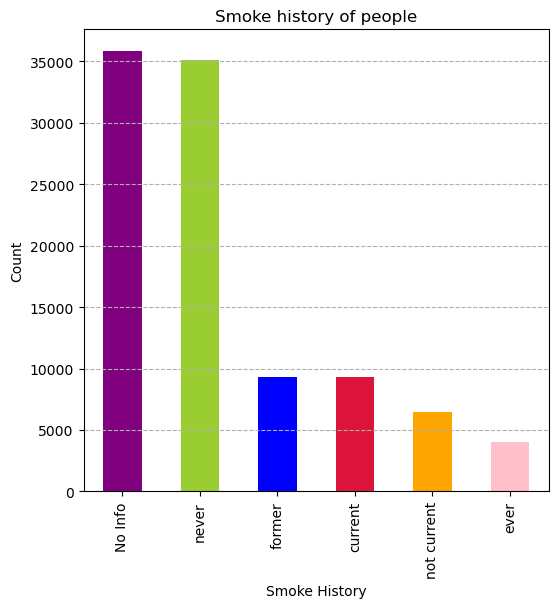

In [27]:

smoke = df['smoking_history'].value_counts()
smoke

plt.figure(figsize=(6,6))
smoke.plot(kind='bar', color=['purple','yellowgreen','blue','crimson','orange','pink'], xlabel='Smoke History', ylabel='Count', title='Smoke history of people')
plt.grid(axis='y', linestyle='--')
plt.show()

We can observe that we do not have the information of smoking history of a lot of people in this dataset. 35095 people have never smoked and 29089 people have some history of smoking